# Introduction to neural network classification with TensorFlow

In this notebook we're going to learn how to write neural networks for classification


A classification is where you try to classify something as one thing or another.
A few types of classification problems
* Binary classification
* Multiclass classification
* Multilabel classification

In [29]:
# Creating data to view and fit

from sklearn.datasets import make_circles

# make 1000 examples
n_samples = 1000


# Create circles
X, y = make_circles(n_samples,
                   noise=0.03,
                   random_state=42)

In [30]:
#Check out features
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]], shape=(1000, 2))

In [31]:
# check the labels
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0])

our data is a little hard to understand right now... let's visualize it.

In [32]:
import pandas as pd

circles = pd.DataFrame({"X0": X[:,0], "X1": X[:, 1]})
circles

,X0,X1
0,0.754246,0.231481
1,-0.756159,0.153259
2,-0.815392,0.173282
3,-0.393731,0.692883
4,0.442208,-0.896723
...,...,...
995,0.244054,0.944125
996,-0.978655,-0.272373
997,-0.136900,-0.810012
998,0.670362,-0.767502


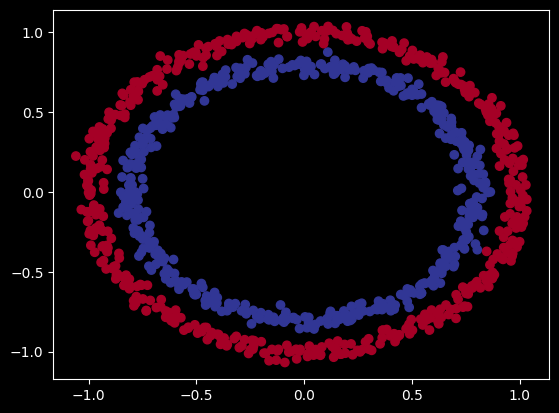

In [33]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

**🛠️ Exercise:** Before pushing forward, spend 10-minutes playing around with [playground.tensorflow.org](playground.tensorflow.org) building and running different neural networks. See what happens when you change different hyperparameters.


### Input and output shapes

In [34]:
# Check the shapes of our features and labels
X.shape, y.shape

((1000, 2), (1000,))

In [35]:
# How many samples we're working
len(X), len(y)

(1000, 1000)

In [36]:
# View the first example of features and labels
X[0], y[0]

(array([0.75424625, 0.23148074]), np.int64(1))

## Steps in modeling
The steps in modeling with TensorFlow are typically:
1. Create or import a model
2. Compile the model
3. Fit the model
4. Evaluate the model
5. Tweak
6. Evaluate..

In [37]:
# Import TensorFlow
import tensorflow as tf
tf.__version__

'2.21.0'

In [38]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create the model using the Sequential API
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# Compile the model
model_1.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(),
    metrics = ["accuracy"]
)

# 3. Fit the model
model_1.fit(X,y, epochs=5)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4650 - loss: 4.4867   
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4620 - loss: 4.4650 
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4640 - loss: 4.4461 
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4610 - loss: 4.3472 
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4610 - loss: 4.2757 


In [39]:
# let's try and improve our model by train for longer...
model_1.fit(X,y, epochs=200, verbose=0)
model_1.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4960 - loss: 0.6932 


[0.6931554079055786, 0.4959999918937683]

Since we're looking on binary classification problem And our model is getting around ~50% accuracy... It's performing as if guessing

So let's step things up a notch and add an extra layer.

In [40]:
#Set the random seed
tf.random.set_seed(42)

# 1. create a model, this time with two layers
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer = tf.keras.optimizers.SGD(),
                metrics = ["accuracy"])

# 3. Fit the model
model_2.fit(X, y, epochs=100, verbose=0)

In [41]:
# 4. Evaluate the model
model_2.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 7.9712 


[7.971191883087158, 0.5]

## Improving our model

Let's look into our bag of tricks to see how we can improve our model.

1. Create a model - We might add more layers of increase the number of hidden units within a layer
2. Compiling a model - Here we might to choose a different optimization function such as Adam instead of SGD.
3. Fitting a model - Perhaps We might fit our model for more epochs (Leave it training for longer)


In [42]:
# Import TensorFlow
import tensorflow as tf
tf.__version__

'2.21.0'

In [43]:
# set the random seed
tf.random.set_seed(42)

# 1. Create the model (this time 3 layers)
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100), # add 100 dense layer neurons
    tf.keras.layers.Dense(10), # add another layer with 10 neurons
    tf.keras.layers.Dense(1)
])


# 2. Compile the model
model_3.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

# 3. Fit the model
X_exp = tf.expand_dims(X, axis=-1)
model_3.fit(X,y, epochs=100, verbose=0)


In [44]:
# 4. Evaluate the model
model_3.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4910 - loss: 0.6945 


[0.6944776773452759, 0.4909999966621399]

To visualize our model's predictions, let's create a function "plot_decision_boundry()", this function will:

* Take in a trained model, features (X) and (y)
* Create a meshgrid of the different X values
* Make a prediction across the meshgrid
* Plot the predictions as well as a line between zones (which unique class falls)

In [45]:
import matplotlib.pyplot as plt
import numpy as np

In [46]:
def plot_decision_boundry(model, X,y):
    """
    Plots the decision boundry created by a model prediction on X
    """
    # Define the axis boundaries of the plot boundaries of the plot and create a meshgrid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Create x values (we're going to make predictions on these)
    x_in = np.c_[xx.ravel(), yy.ravel()] # stack 2D array together

    # Make predictions
    y_pred = model.predict(x_in)

    # Check for multi-class
    if len(y_pred[0]) >1:
        print("doing multiclass classification")
        # We have to reshape our predictions to get them ready for plotting
        y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    else:
        print("Doing binary classification")
        y_pred = np.round(y_pred).reshape(xx.shape)

    # plot the decisions
    plt.contourf(xx,yy,y_pred, cmap = plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 500us/step
Doing binary classification


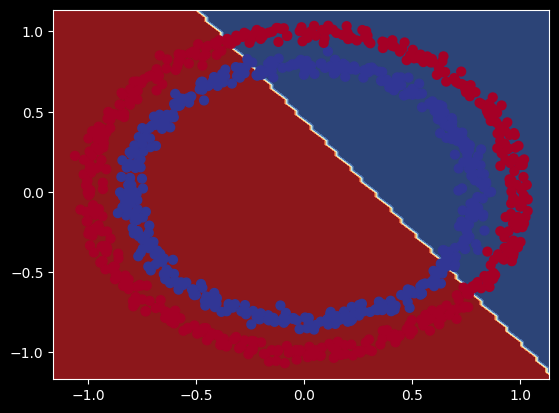

In [47]:
# Check out the predictions our model is making
plot_decision_boundry(model=model_3,X=X, y=y)

In [48]:
# Let's see if our model can be used for regression problem...
tf.random.set_seed(42)

# Create some regression data
X_regression = tf.range(0, 1000, 5)
y_regression = tf.range(100, 1100, 5) # y = X + 100

# Split our regression data into training and test sets
X_reg_train = X_regression[:150]
X_reg_test = X_regression[150:]

y_reg_train = y_regression[:150]
y_reg_test = y_regression[150:]

# Fit our model to regression data

model_3.fit(tf.expand_dims(X_reg_train, axis=-1),
            y_reg_train,
            epochs = 100)


Epoch 1/100


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense_24" is incompatible with the layer: expected axis -1 of input shape to have value 2, but received input with shape (None, 1)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 1), dtype=int32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

Oh! wait... we compiled our model for binary classification problem.

But... we're now working on a regression problem let's change the model to suit our data.

In [49]:
# set the random seed
tf.random.set_seed(42)

# 1. Create the model
model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])


# 2. Compile the model
model_4.compile(
    loss = tf.keras.losses.mae,
    optimizer = tf.keras.optimizers.Adam(),
    metrics=["mae"]
)

# 3. Fit the model
X_reg_train_exp = tf.expand_dims(X_reg_train, axis=-1)
model_4.fit(X_reg_train_exp, y_reg_train, epochs=100)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 402.0921 - mae: 402.0921  
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 256.3035 - mae: 256.3035 
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 107.9714 - mae: 107.9714 
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 66.0769 - mae: 66.0769 
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 91.6299 - mae: 91.6299   
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 60.8549 - mae: 60.8549 
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 50.8756 - mae: 50.8756 
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 49.3499 - mae: 49.3499 
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 45.1545 - mae: 45.1545 
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 44.9473 - mae: 44.9473 
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 42.3349 - mae: 42.3349 
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 41.9746 - mae: 41.9746 
Epoch 13/100
5/5

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


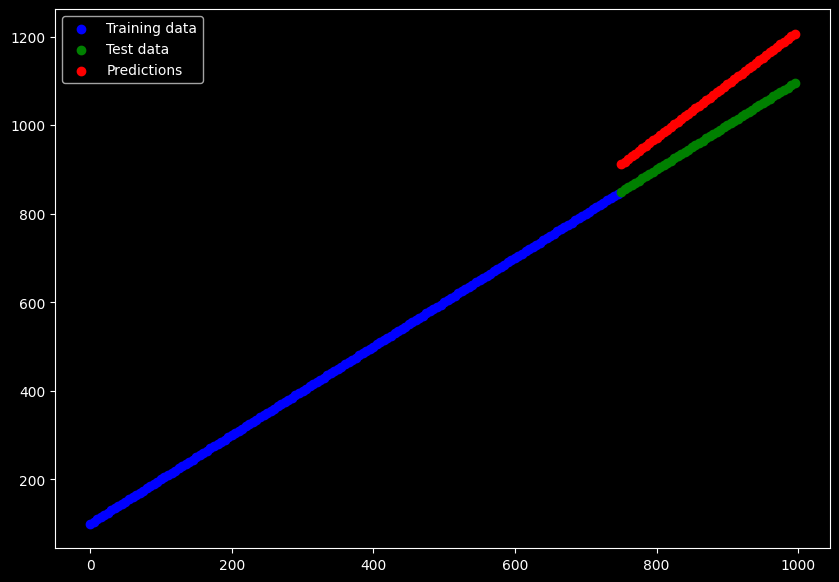

In [50]:
# Make predictions with our trained model
y_reg_pred = model_4.predict(X_reg_test)

# Plot the models predictions against our regression data
plt.figure(figsize = (10,7))
plt.scatter(X_reg_train, y_reg_train, c="b", label= "Training data")
plt.scatter(X_reg_test, y_reg_test, c="g", label = "Test data")
plt.scatter(X_reg_test, y_reg_pred, c ="r", label = "Predictions")
plt.legend()

# The missing piece Non-linearity

In [51]:
import matplotlib.pyplot as plt
import tensorflow as tf
tf.__version__

'2.21.0'

In [52]:

# set the random seed
tf.random.set_seed(42)


# create the model
model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.relu)

])

# compile the model
model_5.compile(loss = "binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate = 0.001),
                metrics=["accuracy"])

# 3. Fit the model
history = model_5.fit(X,y,epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4790 - loss: 5.6799   
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4790 - loss: 5.6593 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4800 - loss: 5.6282 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4780 - loss: 5.5838 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4790 - loss: 5.5761 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4780 - loss: 5.5543 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4770 - loss: 5.5382 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4770 - loss: 5.5143 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4790 - loss: 5.4967 
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4800 - loss: 5.4753 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4800 - loss: 5.4375 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/ste

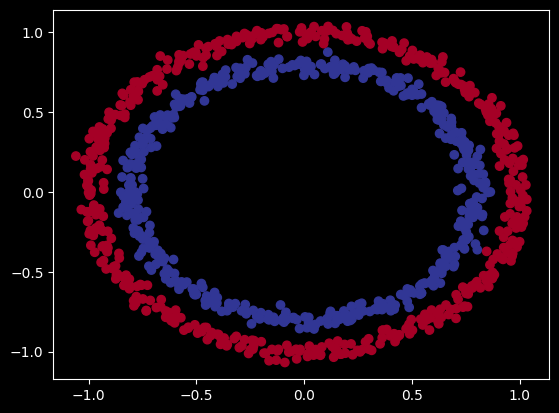

In [53]:
# Check out our data
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 461us/step
Doing binary classification


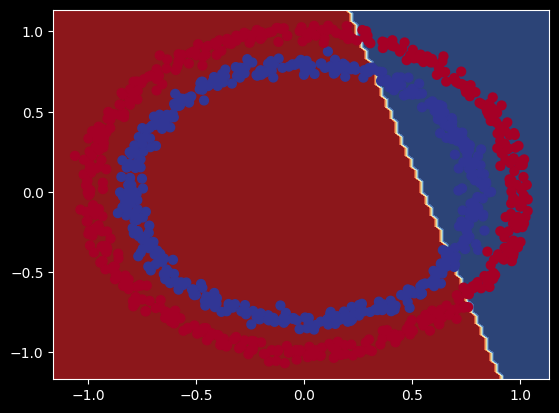

In [54]:
# Check the decision boundary
plot_decision_boundry(model_5, X,y)

In [55]:
import tensorflow as tf

In [56]:
# Time to replicate the multi-layer neural network from TensorFlow Playground

# Set the random seed
tf.random.set_seed(42)

# Create the model
model_7 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1)
])


# 2. Compile the model
model_7.compile(
    loss = tf.keras.losses.BinaryCrossentropy,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

history = model_7.fit(X,y,epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5000 - loss: 5.8162   
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 2.2695 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 1.3411 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 1.2392 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 1.1690 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 1.1119 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 1.0637 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 1.0221 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 0.9859 
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 0.9539 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 0.9257 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/ste

In [57]:
# Evaluate the model
model_7.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5710 - loss: 0.6473 


[0.6472902297973633, 0.5709999799728394]

In [58]:
# Set the random seed
tf.random.set_seed(42)

# Create the model
model_8 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation= tf.keras.activations.sigmoid)
])


# 2. Compile the model
model_8.compile(
    loss = tf.keras.losses.BinaryCrossentropy,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

history = model_8.fit(X,y,epochs=150)

Epoch 1/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5140 - loss: 0.7063
Epoch 2/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4820 - loss: 0.7011 
Epoch 3/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4820 - loss: 0.6981 
Epoch 4/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4790 - loss: 0.6963 
Epoch 5/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4630 - loss: 0.6951 
Epoch 6/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4710 - loss: 0.6941 
Epoch 7/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 0.6933 
Epoch 8/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 0.6926 
Epoch 9/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4870 - loss: 0.6919 
Epoch 10/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4980 - loss: 0.6913 
Epoch 11/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5040 - loss: 0.6907 
Epoch 12/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step -

In [59]:
# evaluate our model
model_8.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9640 - loss: 0.2179 


[0.2179209142923355, 0.9639999866485596]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 500us/step
Doing binary classification


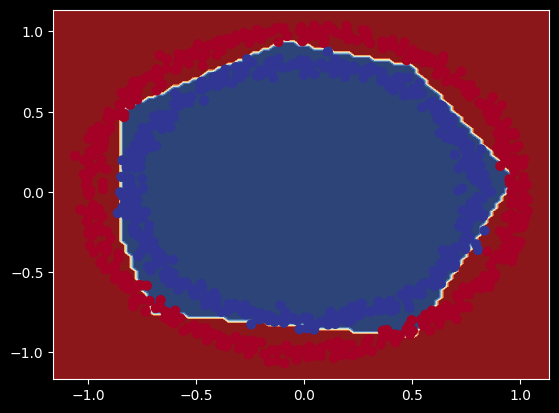

In [60]:
plot_decision_boundry(model_8, X,y)

🤔** Question :** What's wrong the predictions we've made? Are
we really evaluating our model correctly? Hint: what data did
the model learn on and what data did we predict on?

🗝️** Note: ** The combination of ** linear (straight lines) and
non-linear (non-straight lines) functions ** is one of the key
fundamentals of neural networks.

Now we've discussed the concept of linear and non-linear
functions (or lines), let's see them in action.

In [61]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [62]:
# Create a toy tensor (similar to the data we pass into our models)
A = tf.cast(tf.range(-10, 10), tf.float32)
A

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.],
      dtype=float32)>

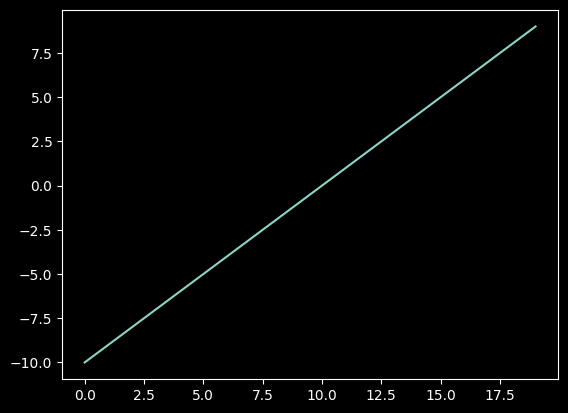

In [63]:
# Visualize our toy tensor
plt.plot(A)

In [64]:
# Let's start by replicating sigmoid - sigmoid(x) = 1 / (1 + exp(-x))
def sigmoid(x):
    return 1 / (1 + tf.exp(-x))

print(A)
#Use the sigmoid function on our toy tensor
print(sigmoid(A))


tf.Tensor(
[-10.  -9.  -8.  -7.  -6.  -5.  -4.  -3.  -2.  -1.   0.   1.   2.   3.
   4.   5.   6.   7.   8.   9.], shape=(20,), dtype=float32)
tf.Tensor(
[4.5397872e-05 1.2339458e-04 3.3535014e-04 9.1105117e-04 2.4726233e-03
 6.6928510e-03 1.7986210e-02 4.7425874e-02 1.1920292e-01 2.6894143e-01
 5.0000000e-01 7.3105860e-01 8.8079703e-01 9.5257413e-01 9.8201376e-01
 9.9330717e-01 9.9752742e-01 9.9908900e-01 9.9966466e-01 9.9987662e-01], shape=(20,), dtype=float32)


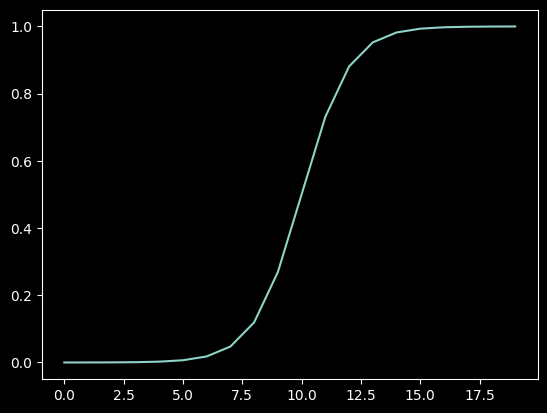

In [65]:
# Plot our toy tensor transformed by sigmoid
plt.plot(sigmoid(A))

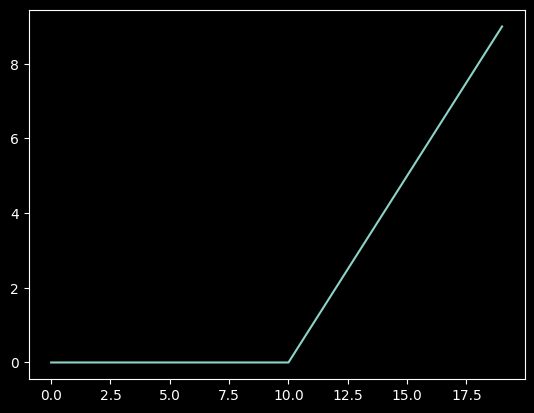

In [66]:
#Let's recreate relu function

def relu(x):
    return [max(i,0) for i in x]

plt.plot(relu(A))

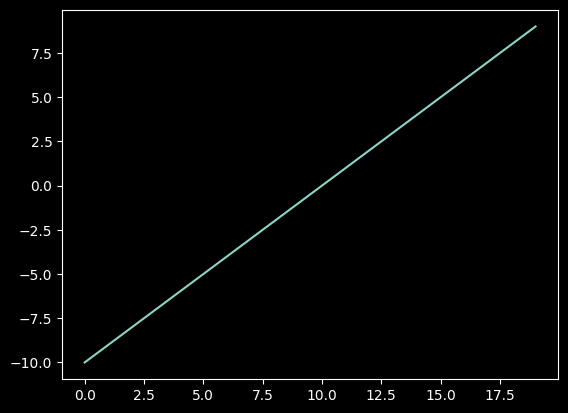

In [67]:
plt.plot(tf.keras.activations.linear(A))

In [68]:
A == tf.keras.activations.linear(A)

<tf.Tensor: shape=(20,), dtype=bool, numpy=
array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])>

## Evaluating and improving our classification
So far we've been training and testing on the same dataset...

However, in machine learning this is basically sin.

So let's create a training and test set.

In [69]:
# Check how many examples we have
len(X)

1000

In [70]:
#Split into train and test sets

X_train, y_train = X[:800], y[:800]
X_test, y_test = X[800:], y[800:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 2), (200, 2), (800,), (200,))

In [71]:
# Let's recreate a model to fit and training data and evaluate on the testing data

#set random seat
tf.random.set_seed(42)


# 1. Create the model (same as model_7)
model_9 =  tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])


# 2. Compile the model
model_9.compile(
    loss = "binary_crossentropy",
    optimizer= tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"])


# 3. Fit the model
history_9 = model_9.fit(X_train,y_train,epochs=25)

Epoch 1/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4925 - loss: 0.6912   
Epoch 2/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5200 - loss: 0.6871 
Epoch 3/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5312 - loss: 0.6810 
Epoch 4/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6162 - loss: 0.6674 
Epoch 5/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7312 - loss: 0.6397 
Epoch 6/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8000 - loss: 0.6001 
Epoch 7/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8487 - loss: 0.5464 
Epoch 8/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9137 - loss: 0.4672 
Epoch 9/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9688 - loss: 0.3790 
Epoch 10/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9812 - loss: 0.3040 
Epoch 11/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9912 - loss: 0.2490 
Epoch 12/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy

In [72]:
# Evaluate the model on the test dataset
model_9.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9900 - loss: 0.0579 


[0.05788736417889595, 0.9900000095367432]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 504us/step
Doing binary classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 448us/step
Doing binary classification


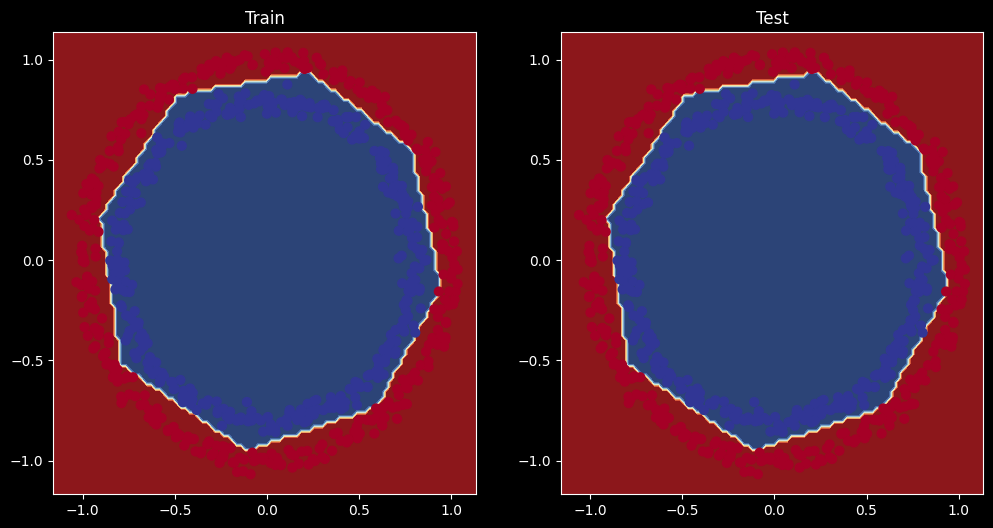

In [73]:
# Plot the decision boundaries for the training and test sets
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundry(model_9, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundry(model_9, X_train, y_train)
plt.show()

In [74]:
# convert the history object into a DataFrame
import pandas as pd

pd.DataFrame(history.history)

,accuracy,loss
0,0.514,0.706293
1,0.482,0.701061
2,0.482,0.698097
3,0.479,0.696329
4,0.463,0.695103
...,...,...
145,0.958,0.230137
146,0.958,0.227460
147,0.957,0.224845
148,0.958,0.222321


Text(0.5, 1.0, 'model_9 loss curves')

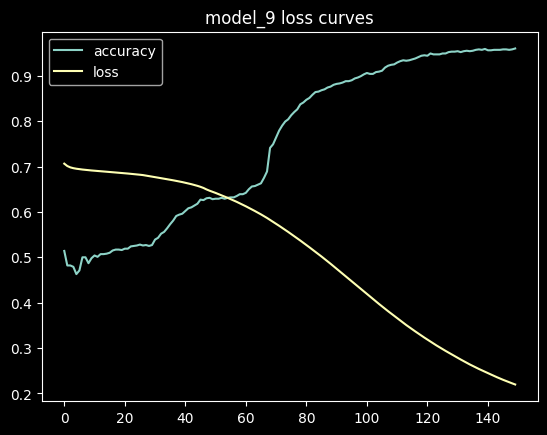

In [75]:
pd.DataFrame(history.history).plot()
plt.title("model_9 loss curves")

I🗝️ **Note:** For many problems, the loss function going down means the model is improving (It's making are getting closer to the ground truth labels.)

## Finding the best learning rate

To find the ideal learning rate (the learning rate were the loss decrease the most during training) We're Going to use the following steps:

* A learning rate **callback** -  You can't think of a callback as an extra piece of functionality you can add to your *while* it's training

* Another model (we could use the same one as above but we are practicing building models here)

* A modified Lost Curves plot.


In [76]:
# Set random seed
tf.random.set_seed(42)

# Create a model (same as model_9)
model_10 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="relu"),
])

# Compile the model
model_10.compile(
    loss = "binary_crossentropy",
    optimizer="Adam",
    metrics=["accuracy"]
)

# Create a learning rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10** (epoch/20))


# Fit the model (Passing lr_scheduler callback)
history_10 = model_10.fit(
    X_train,
    y_train,
    epochs=100,
    callbacks=[lr_scheduler]
)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4988 - loss: 5.5088 - learning_rate: 1.0000e-04
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4988 - loss: 4.9831 - learning_rate: 1.1220e-04
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4988 - loss: 4.8792 - learning_rate: 1.2589e-04
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4988 - loss: 4.8486 - learning_rate: 1.4125e-04
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4988 - loss: 4.8154 - learning_rate: 1.5849e-04
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4988 - loss: 4.7895 - learning_rate: 1.7783e-04
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4988 - loss: 4.7313 - learning_rate: 1.9953e-04
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4988 - loss: 4.6910 - learning_rate: 2.2387e-04
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4988 - loss: 4.6623 - learning_

<Axes: xlabel='epochs'>

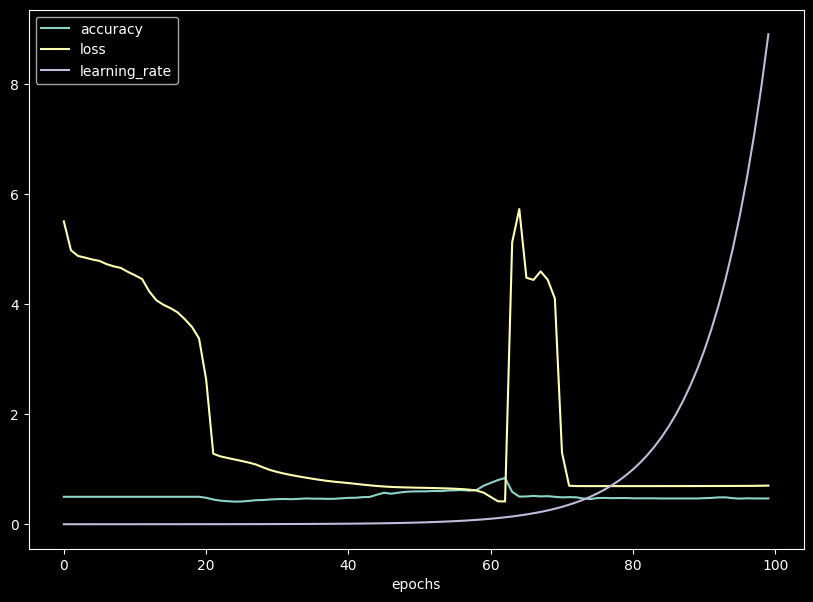

In [77]:
# Check out the history
pd.DataFrame(history_10.history).plot(figsize=(10,7), xlabel = "epochs")

Text(0.5, 1.0, 'Learning rate vs. Loss')

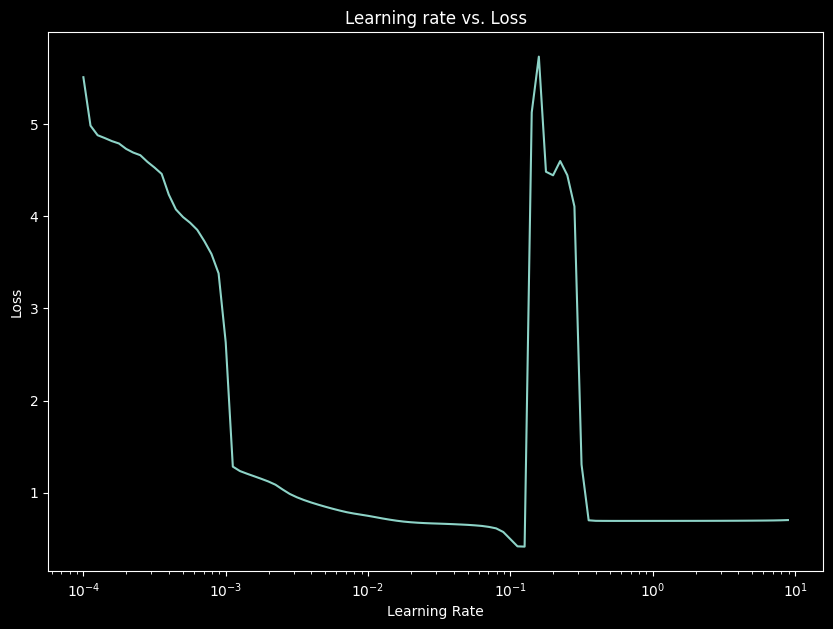

In [78]:
lrs = 1e-4 * (10 ** (tf.range(100)/20))
plt.figure(figsize=(10,7))
plt.semilogx(lrs, history_10.history["loss"])
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning rate vs. Loss")


In [79]:
# Examples of other typical learning rates values:
10**0, 10**-1, 10 ** -2, 10**-3, 1e-4

(1, 0.1, 0.01, 0.001, 0.0001)

---


In [80]:
import tensorflow as tf

In [89]:
# 0.03 for me


tf.random.set_seed(42)

model_11 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])


model_11.compile(loss = "binary_crossentropy",
                 optimizer=tf.keras.optimizers.Adam(learning_rate = 0.02),
                 metrics = ["accuracy"])

model_11.fit(X_train, y_train, epochs=20)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5138 - loss: 0.6879   
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5788 - loss: 0.6752 
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6125 - loss: 0.6568 
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7175 - loss: 0.6170 
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7788 - loss: 0.5463 
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8637 - loss: 0.4487 
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9400 - loss: 0.3423 
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9625 - loss: 0.2637 
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9762 - loss: 0.2084 
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9762 - loss: 0.1686 
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9850 - loss: 0.1352 
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy

In [90]:
model_11.evaluate(X_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9900 - loss: 0.0435 


[0.04349539801478386, 0.9900000095367432]

In [91]:
model_9.evaluate(X_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9900 - loss: 0.0579 


[0.05788736417889595, 0.9900000095367432]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 513us/step
Doing binary classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 464us/step
Doing binary classification


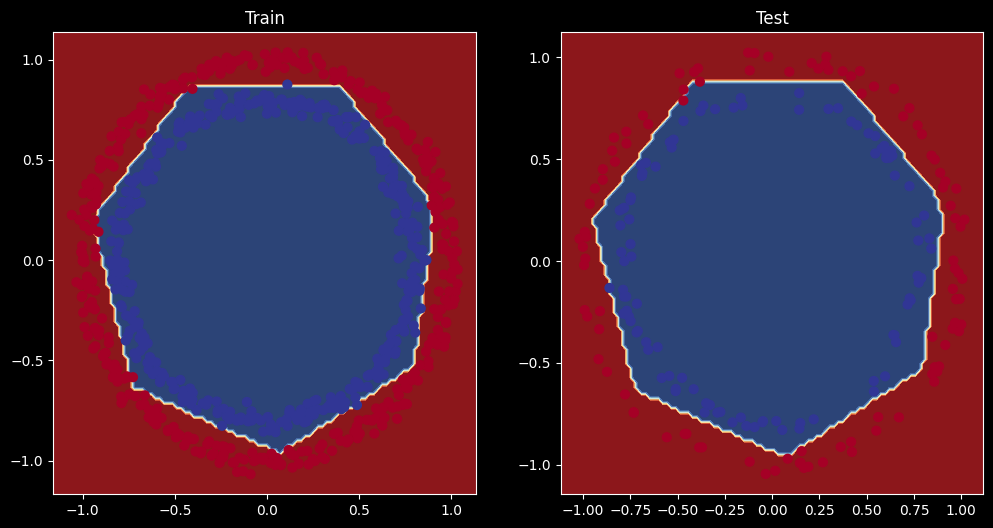

In [92]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundry(model_11, X_train,y_train)

plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundry(model_11, X_test,y_test)
